In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_excel('/content/FullData.xlsx')

In [ ]:
data

,text,Dialect,confidence
0,بدي اروح عالبيت هلأ,ammani,high
1,باجي بعد شوي، ما تستناني كتير,ammani,high
2,بدي اروح عالمول اليوم الصبح قبل ما يصير ازمة، ...,ammani,high
3,بدي راتب يكفيني لنص الشهر على الأقل، مش كل شهر...,ammani,high
4,باجي عالسوق أشتري شغلتين، وبرجع محمّل بكيسين ب...,ammani,high
...,...,...,...
9550,اللي بقدر اقدموا ليكوا,karaki,Medium
9551,عنا تشثير من المميزات,karaki,High
9552,ازمطها والحقني,karaki,High
9553,لويه يا استاذ,karaki,High


In [ ]:
data.shape

(9555, 3)

In [ ]:

data['Dialect'].value_counts()

,count
Dialect,
ammani,2121
falahi,2054
Bedouin,2000
karaki,1994
Ammani,737
Fallahi,649


In [ ]:


# Standardize 'ammani' to 'Ammani' and 'falahi' to 'Fallahi' while keeping other values
data['Dialect'] = data['Dialect'].replace({
    "ammani": "Ammani",
    "falahi": "Fallahi"
})

# Display the updated value counts for the 'Dialect' column
data['Dialect'].value_counts()

,count
Dialect,
Ammani,2858
Fallahi,2703
Bedouin,2000
karaki,1994


In [ ]:
import matplotlib.pyplot as plt

<BarContainer object of 4 artists>

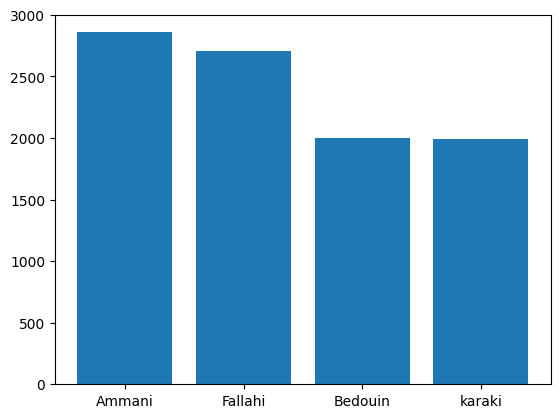

In [ ]:
plt.bar(data['Dialect'].value_counts().index,data['Dialect'].value_counts())


In [ ]:

data[data['text'].isnull()]

,text,Dialect,confidence


In [ ]:
data.duplicated().sum()

np.int64(978)

In [ ]:
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(8577, 3)

In [ ]:
data['Dialect'].value_counts()

,count
Dialect,
Ammani,2856
Fallahi,2699
karaki,1982
Bedouin,1040


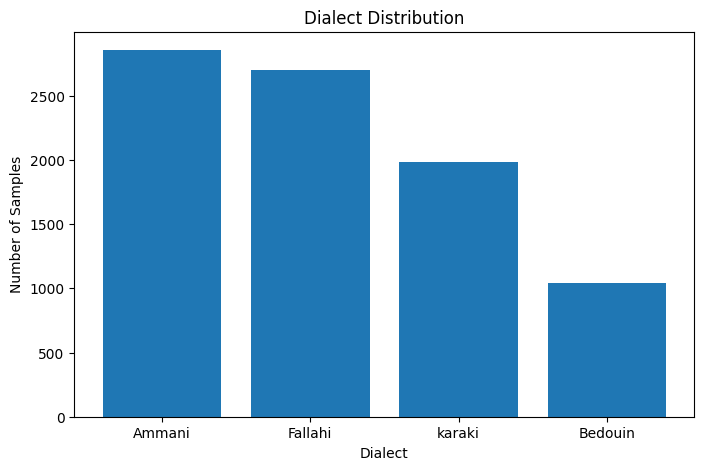

In [ ]:
plt.figure(figsize=(8,5))

counts = data['Dialect'].value_counts()

plt.bar(counts.index, counts.values)

plt.title("Dialect Distribution")
plt.xlabel("Dialect")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
import re
import unicodedata
import pandas as pd
from collections import Counter


# ==============================================================================
# Arabic cleaning rules
# ==============================================================================

ARABIC_DIACRITICS = re.compile(r'[\u0610-\u061A\u064B-\u065F\u0670]')
TATWEEL           = re.compile(r'\u0640')
NON_ARABIC        = re.compile(r'[^\u0600-\u06FF\s]')
REPEATED_CHARS    = re.compile(r'(.)\1{2,}')
ALEF_VARIANTS     = re.compile(r'[إأآا]')
YEH_VARIANTS      = re.compile(r'[ىي]')
TEH_MARBUTA       = re.compile(r'ة')

# Core function words with little dialect signal.
# Dialect markers (شو، وين، هيك، زي) are intentionally kept.
ARABIC_STOPWORDS = {
    'في', 'من', 'إلى', 'على', 'عن', 'مع', 'هذا', 'هذه', 'هو', 'هي',
    'نحن', 'انتم', 'هم', 'كان', 'كانت', 'يكون', 'ان', 'اذا', 'لكن',
    'او', 'ام', 'لا', 'ما', 'لم', 'لن', 'قد', 'قط', 'كل', 'بعض',
    'ثم', 'حتى', 'بين', 'عند', 'منذ', 'خلال', 'بسبب', 'رغم'
}


def clean_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFC", text)

    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove diacritics and tatweel
    text = ARABIC_DIACRITICS.sub('', text)
    text = TATWEEL.sub('', text)

    # Remove non-Arabic characters
    text = NON_ARABIC.sub(' ', text)

    # Normalize letter variants
    text = ALEF_VARIANTS.sub('ا', text)
    text = YEH_VARIANTS.sub('ي', text)
    text = TEH_MARBUTA.sub('ه', text)

    # Collapse repeated characters (e.g. حلووووو → حلوو)
    text = REPEATED_CHARS.sub(r'\1\1', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def remove_stopwords(text: str) -> str:
    tokens = text.split()
    return ' '.join(t for t in tokens if t not in ARABIC_STOPWORDS)


def preprocess_text(text: str) -> str:
    return remove_stopwords(clean_arabic(text))


In [ ]:
# applies the function to each row
data['text_clean'] = data['text'].apply(preprocess_text)

In [ ]:
data

,text,Dialect,confidence,text_clean
0,بدي اروح عالبيت هلأ,Ammani,high,بدي اروح عالبيت هلا
1,باجي بعد شوي، ما تستناني كتير,Ammani,high,باجي بعد شوي، تستناني كتير
2,بدي اروح عالمول اليوم الصبح قبل ما يصير ازمة، ...,Ammani,high,بدي اروح عالمول اليوم الصبح قبل يصير ازمه، اشت...
3,بدي راتب يكفيني لنص الشهر على الأقل، مش كل شهر...,Ammani,high,بدي راتب يكفيني لنص الشهر علي الاقل، مش شهر نف...
4,باجي عالسوق أشتري شغلتين، وبرجع محمّل بكيسين ب...,Ammani,high,باجي عالسوق اشتري شغلتين، وبرجع محمل بكيسين بد...
...,...,...,...,...
8572,اللي بقدر اقدموا ليكوا,karaki,Medium,اللي بقدر اقدموا ليكوا
8573,عنا تشثير من المميزات,karaki,High,عنا تشثير المميزات
8574,ازمطها والحقني,karaki,High,ازمطها والحقني
8575,لويه يا استاذ,karaki,High,لويه يا استاذ


In [ ]:
print("\nSample before/after cleaning:")
for _, row in data.head(3).iterrows():
        print(f"  Before: {row['text']}")
        print(f"  After : {row['text_clean']}")
        print()



Sample before/after cleaning:
  Before: بدي اروح عالبيت هلأ
  After : بدي اروح عالبيت هلا

  Before: باجي بعد شوي، ما تستناني كتير
  After : باجي بعد شوي، تستناني كتير

  Before: بدي اروح عالمول اليوم الصبح قبل ما يصير ازمة،  أشتري خضار وفواكه للبيت، وبعدها باجي عندكم نقعد شوي عالبيت نسهر ونشرب شاي 
  After : بدي اروح عالمول اليوم الصبح قبل يصير ازمه، اشتري خضار وفواكه للبيت، وبعدها باجي عندكم نقعد شوي عالبيت نسهر ونشرب شاي



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np


In [ ]:
# 1. Encode labels
le = LabelEncoder()
y = le.fit_transform(data['Dialect'])


In [ ]:
# 2. Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data['text_clean'], y,
    test_size=0.2,
    stratify=y,  # Maintains same dialect distribution in both sets (important for imbalanced data)
    random_state=42
)


In [ ]:
# 3. TF-IDF
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2,5),
    max_features=50000,
    sublinear_tf=True,
    min_df=2)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)


In [ ]:
from sklearn.svm import LinearSVC

clf = LinearSVC(
    class_weight='balanced',     # Penalize misclassifying minority classes more   / Balanced weights = misclassifying a Bedouin sample costs more
    max_iter=2000)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      Ammani       0.91      0.92      0.92       571
     Bedouin       0.78      0.78      0.78       208
     Fallahi       0.79      0.81      0.80       540
      karaki       0.85      0.81      0.83       397

    accuracy                           0.84      1716
   macro avg       0.83      0.83      0.83      1716
weighted avg       0.84      0.84      0.84      1716



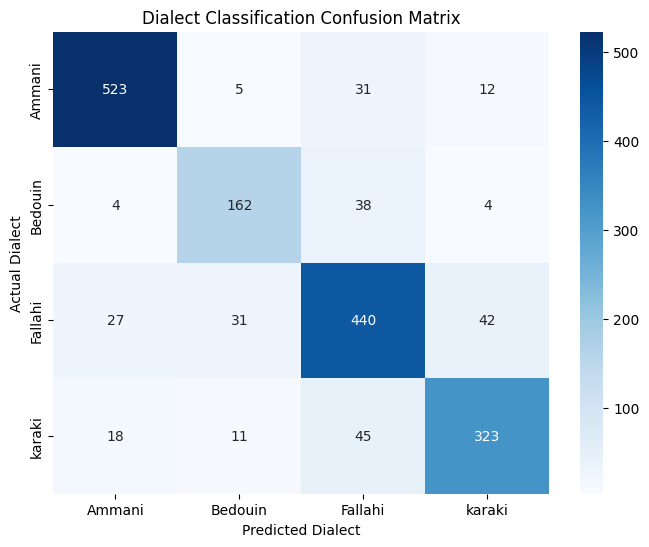

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# Confusion Matrix
# -------------------------

cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for labels
cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

# -------------------------
# Heatmap Visualization
# -------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Dialect Classification Confusion Matrix")
plt.xlabel("Predicted Dialect")
plt.ylabel("Actual Dialect")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LinearSVC(class_weight='balanced', max_iter=2000),
                    param_grid, cv=5, scoring='f1_macro')
grid.fit(X_train, y_train)
print("Best C:", grid.best_params_)

Best C: {'C': 1}


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# best model from GridSearchCV
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# predictions
y_pred = best_model.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8438228438228438

Confusion Matrix:
 [[523   5  31  12]
 [  4 162  38   4]
 [ 27  31 440  42]
 [ 18  11  45 323]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       571
           1       0.78      0.78      0.78       208
           2       0.79      0.81      0.80       540
           3       0.85      0.81      0.83       397

    accuracy                           0.84      1716
   macro avg       0.83      0.83      0.83      1716
weighted avg       0.84      0.84      0.84      1716



In [ ]:
errors = pd.DataFrame({
    "original_text": X_test_raw.values,
    "actual": le.inverse_transform(y_test),
    "predicted": le.inverse_transform(y_pred)
})
errors = errors[errors["actual"] != errors["predicted"]]
print("Number of wrong predictions:", len(errors))
errors.head(20)

Number of wrong predictions: 268


,original_text,actual,predicted
10,روح زت هالشاكوش ايدك,Ammani,Fallahi
11,ظهره صغيره,karaki,Fallahi
13,الله يجزيك خير,Fallahi,Bedouin
16,فتحت الشباك تاتفوت الشمس وتهوي الغرفه,Fallahi,karaki
31,زرعات السنه جابن خير وبركه,Fallahi,Bedouin
43,عندنا كهربا الليل,Fallahi,Bedouin
44,تحجل عليك,karaki,Fallahi
65,صلحنا المزراب قبل الشتا,karaki,Fallahi
75,الدنيا حلوه تعكرها,Bedouin,Fallahi
92,عنده منوحه,Fallahi,karaki


## Conclusion

This model achieves 84.4% accuracy in classifying 4 Jordanian Arabic dialects (Ammani, Fallahi, Bedouin, Karaki) using character n-gram features with LinearSVC. The approach is effective because character patterns capture dialect-specific pronunciation and morphological differences that word-level features miss.

Performance is strongest for Ammani (largest training set) and weakest for Bedouin (smallest training set). Future work could collect more Bedouin samples and explore deep learning methods.